# 📊 End-to-End Customer Analytics & Revenue Forecasting

## Python | Pandas | NumPy | Matplotlib | Scikit-learn

**Business Goal:** Understand customer behavior, revenue drivers, churn patterns and build a **Linear Regression model** to estimate customer revenue.

### Project workflow
1. Data loading & business understanding
2. Data quality audit
3. Data cleaning
4. Feature engineering
5. Exploratory data analysis
6. Business insights
7. Linear Regression modeling
8. Model evaluation
9. Business recommendations

> **Important modeling note:** `total_revenue` is the target. Features derived directly from it, such as `revenue_per_month`, `revenue_category`, and `high_value_customer`, are excluded from the regression model to avoid target leakage.


In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Dataset

In [2]:
# Keep subscription_data.csv in the same folder as this notebook.
file_path = "subscription_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (2560, 15)


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.00,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.00,Referral,Yes,"30,167.90"
1,10002,46.00,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.00,Organic,Yes,"27,642.40"
2,10003,32.00,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.00,Referral,No,"3,092.85"
3,10004,60.00,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.00,Organic,No,"2,180.00"
4,10005,25.00,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.00,Ads,No,"39,796.90"


## 3. Data Understanding

We first answer:
- How many rows and columns?
- What are the data types?
- What does each variable look like?
- Are there missing values, duplicates or invalid values?


In [3]:
# Basic structure
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nStatistical summary:")
display(df.describe(include="all").T)


Rows: 2560
Columns: 15

Data types:


,dtype
customer_id,int64
age,float64
gender,str
city,str
signup_date,str
last_active_date,str
plan_type,str
monthly_fee,int64
tenure_months,int64
support_tickets,int64



Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,"2,560.00",NaN,NaN,NaN,"11,250.55",721.67,"10,001.00","10,625.75","11,252.50","11,874.25","12,500.00"
age,"2,455.00",NaN,NaN,NaN,41.16,13.56,18.00,29.00,41.00,53.00,64.00
gender,2560,3,Female,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,2456,6,Mumbai,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,2560,852,3/10/2023,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_active_date,2560,837,7/22/2022,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_type,2560,3,Basic,1122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_fee,"2,560.00",NaN,NaN,NaN,900.63,347.39,300.00,592.75,909.00,"1,203.00","1,499.00"
tenure_months,"2,560.00",NaN,NaN,NaN,17.82,10.07,1.00,9.00,17.50,26.00,35.00
support_tickets,"2,560.00",NaN,NaN,NaN,2.10,1.48,0.00,1.00,2.00,3.00,8.00


## 4. Missing Value Analysis

,missing_count,missing_percent
age,105,4.10
discount_percent,105,4.10
city,104,4.06
avg_session_time,101,3.95


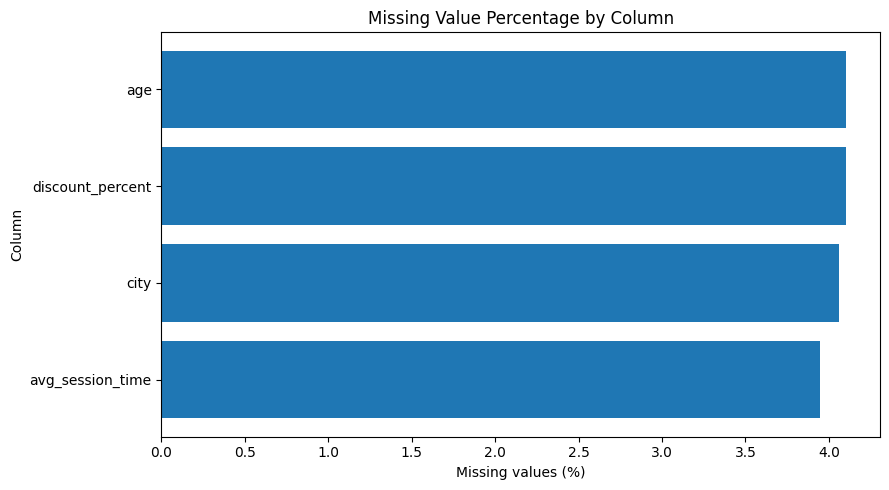

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing[missing["missing_count"] > 0].round(2))

# Visualize missing values
missing_plot = missing[missing["missing_count"] > 0].sort_values("missing_percent")
plt.figure(figsize=(9, 5))
plt.barh(missing_plot.index, missing_plot["missing_percent"])
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missing Value Percentage by Column")
plt.tight_layout()
plt.show()


## 5. Duplicate & Data Integrity Checks

In [5]:
# Duplicate rows
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

# Customer ID uniqueness
print("Unique customer IDs:", df["customer_id"].nunique())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

# Age validation
invalid_age = ((df["age"] < 18) | (df["age"] > 80)).sum()
print("Invalid age records (age < 18 or age > 80):", invalid_age)

# Date validation
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
df["last_active_date"] = pd.to_datetime(df["last_active_date"], errors="coerce")

invalid_dates = (df["last_active_date"] < df["signup_date"]).sum()
print("Illogical date records (last active < signup):", invalid_dates)

print("\nInvalid-date examples:")
display(df.loc[df["last_active_date"] < df["signup_date"],
               ["customer_id", "signup_date", "last_active_date"]].head())


Duplicate rows: 60
Unique customer IDs: 2500
Duplicate customer IDs: 60
Invalid age records (age < 18 or age > 80): 0
Illogical date records (last active < signup): 877

Invalid-date examples:


,customer_id,signup_date,last_active_date
3,10004,2022-11-13,2021-07-08
4,10005,2022-02-17,2021-06-25
6,10007,2022-12-01,2022-09-04
8,10009,2023-03-12,2022-07-22
10,10011,2022-09-01,2022-06-18


### Cleaning decisions

| Problem | Treatment |
|---|---|
| Duplicate rows | Remove exact duplicate records |
| `age` missing | Fill with median age |
| `city` missing | Fill with `"Unknown"` |
| `avg_session_time` missing | Fill with median |
| `discount_percent` missing | Fill with median |
| Invalid age | No invalid age found in this dataset |
| `last_active_date < signup_date` | Set `last_active_date = signup_date` so activity duration cannot become negative |
| Dates | Convert to pandas datetime |

**Why not simply delete all invalid dates?** The dataset contains a substantial number of date-order issues. Correcting the impossible relationship preserves customers while making the derived `days_active` metric logically valid. In a production system, the source system should also be investigated.


## 6. Data Cleaning

In [6]:
# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Missing-value treatment
df["age"] = df["age"].fillna(df["age"].median())
df["city"] = df["city"].fillna("Unknown")
df["avg_session_time"] = df["avg_session_time"].fillna(df["avg_session_time"].median())
df["discount_percent"] = df["discount_percent"].fillna(df["discount_percent"].median())

# Fix illogical activity dates
bad_date_mask = df["last_active_date"] < df["signup_date"]
df.loc[bad_date_mask, "last_active_date"] = df.loc[bad_date_mask, "signup_date"]

print("Cleaned shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())
print("Negative activity durations:",
      (df["last_active_date"] < df["signup_date"]).sum())


Cleaned shape: (2500, 15)
Remaining missing values: 0
Remaining duplicate rows: 0
Negative activity durations: 0


# 7. Feature Engineering

We create business-friendly features that can support segmentation, reporting and modeling.

In [7]:
# 15. Customer tenure in years
df["customer_tenure_years"] = df["tenure_months"] / 12

# 16. Revenue per subscribed month
df["revenue_per_month"] = (
    df["total_revenue"] / df["tenure_months"].replace(0, np.nan)
)

# 17. Binary churn flag
df["churn_flag"] = df["churned"].eq("Yes").astype(int)

# 18. Age group
df["age_group"] = np.select(
    [
        df["age"] < 25,
        df["age"] < 45
    ],
    [
        "Young",
        "Middle"
    ],
    default="Senior"
)

# 19. High-value customer
revenue_median = df["total_revenue"].median()
df["high_value_customer"] = np.where(
    df["total_revenue"] > revenue_median, "Yes", "No"
)

# 20. Days active
df["days_active"] = (
    df["last_active_date"] - df["signup_date"]
).dt.days

# 21. Session usage category
df["session_usage_category"] = np.select(
    [
        df["avg_session_time"] < 30,
        df["avg_session_time"] < 60
    ],
    [
        "Low",
        "Medium"
    ],
    default="High"
)

# 22. Discount category
df["discount_category"] = np.select(
    [
        df["discount_percent"].eq(0),
        df["discount_percent"] <= 10
    ],
    [
        "No Discount",
        "Low Discount"
    ],
    default="High Discount"
)

# 23-24. Signup month and year
df["signup_month"] = df["signup_date"].dt.month_name()
df["signup_year"] = df["signup_date"].dt.year

# 25. Support intensity
df["support_intensity"] = np.where(
    df["support_tickets"] >= 5, "High", "Low"
)

# 26. Revenue category
df["revenue_category"] = np.select(
    [
        df["total_revenue"] < 10000,
        df["total_revenue"] < 30000
    ],
    [
        "Low",
        "Medium"
    ],
    default="High"
)

# 27. Plan rank
df["plan_rank"] = df["plan_type"].map({
    "Basic": 1,
    "Standard": 2,
    "Premium": 3
})

# 28. Engagement score
df["engagement_score"] = (
    df["avg_session_time"] / (df["support_tickets"] + 1)
)

display(df.head())


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue,customer_tenure_years,revenue_per_month,churn_flag,age_group,high_value_customer,days_active,session_usage_category,discount_category,signup_month,signup_year,support_intensity,revenue_category,plan_rank,engagement_score
0,10001,56.00,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,15.75,15.00,Referral,Yes,"30,167.90",2.08,"1,206.72",1,Senior,Yes,26,Low,High Discount,December,2022,High,High,1,2.62
1,10002,46.00,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,37.16,20.00,Organic,Yes,"27,642.40",1.83,"1,256.47",1,Senior,Yes,307,Medium,High Discount,March,2021,Low,Medium,3,18.58
2,10003,32.00,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,41.93,5.00,Referral,No,"3,092.85",0.33,773.21,0,Middle,No,56,Medium,Low Discount,June,2023,Low,Low,1,41.93
3,10004,60.00,Male,Delhi,2022-11-13,2022-11-13,Standard,545,4,1,116.41,0.00,Organic,No,"2,180.00",0.33,545.00,0,Senior,No,0,High,No Discount,November,2022,Low,Low,2,58.20
4,10005,25.00,Female,Mumbai,2022-02-17,2022-02-17,Basic,1331,30,1,81.89,10.00,Ads,No,"39,796.90",2.50,"1,326.56",0,Middle,Yes,0,High,Low Discount,February,2022,Low,High,1,40.95


### Engagement Score

$$
\text{Engagement Score} =
\frac{\text{avg_session_time}}
{\text{support_tickets}+1}
$$

A higher score means more usage with fewer support issues.  
The `+1` prevents division by zero and the denominator penalizes customers who raise more support tickets.


# 8. KPI Dashboard

In [8]:
total_customers = df["customer_id"].nunique()
total_revenue = df["total_revenue"].sum()
avg_revenue = df["total_revenue"].mean()
median_revenue = df["total_revenue"].median()
churn_rate = df["churn_flag"].mean() * 100
avg_tenure = df["tenure_months"].mean()

kpi = pd.DataFrame({
    "KPI": [
        "Customers", "Total Revenue", "Average Revenue",
        "Median Revenue", "Churn Rate", "Average Tenure (months)"
    ],
    "Value": [
        f"{total_customers:,}",
        f"₹{total_revenue:,.2f}",
        f"₹{avg_revenue:,.2f}",
        f"₹{median_revenue:,.2f}",
        f"{churn_rate:.2f}%",
        f"{avg_tenure:.2f}"
    ]
})
display(kpi)


,KPI,Value
0,Customers,"2,500"
1,Total Revenue,"₹39,774,709.50"
2,Average Revenue,"₹15,909.88"
3,Median Revenue,"₹13,457.83"
4,Churn Rate,23.44%
5,Average Tenure (months),17.78


# 9. A. Data Understanding & Distribution

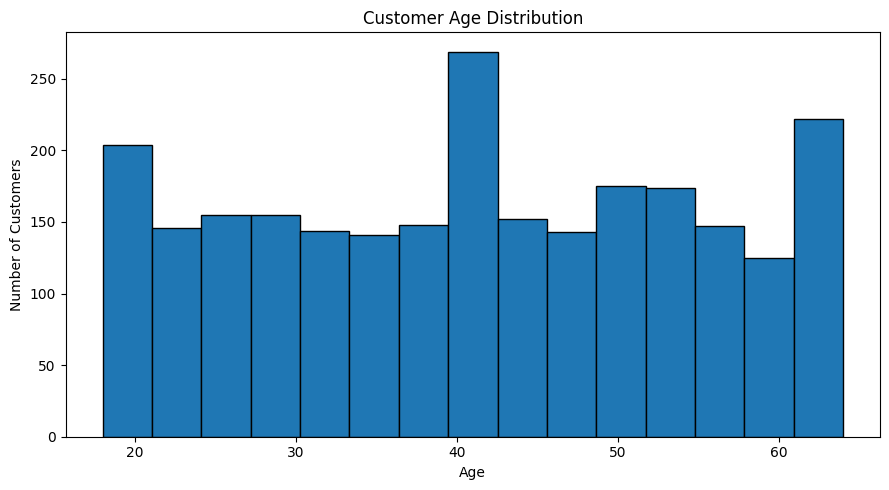

In [9]:
# 1. Age distribution
plt.figure(figsize=(9, 5))
plt.hist(df["age"], bins=15, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.tight_layout()
plt.show()


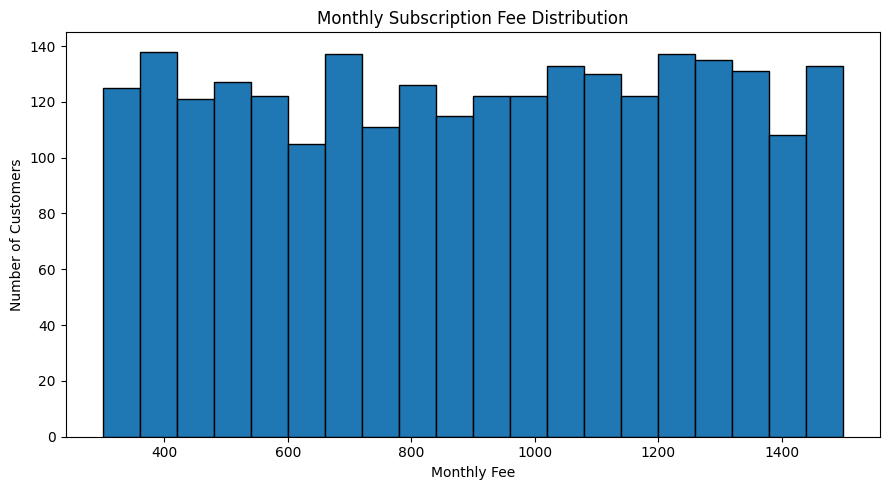

In [10]:
# 2. Monthly fee distribution
plt.figure(figsize=(9, 5))
plt.hist(df["monthly_fee"], bins=20, edgecolor="black")
plt.xlabel("Monthly Fee")
plt.ylabel("Number of Customers")
plt.title("Monthly Subscription Fee Distribution")
plt.tight_layout()
plt.show()


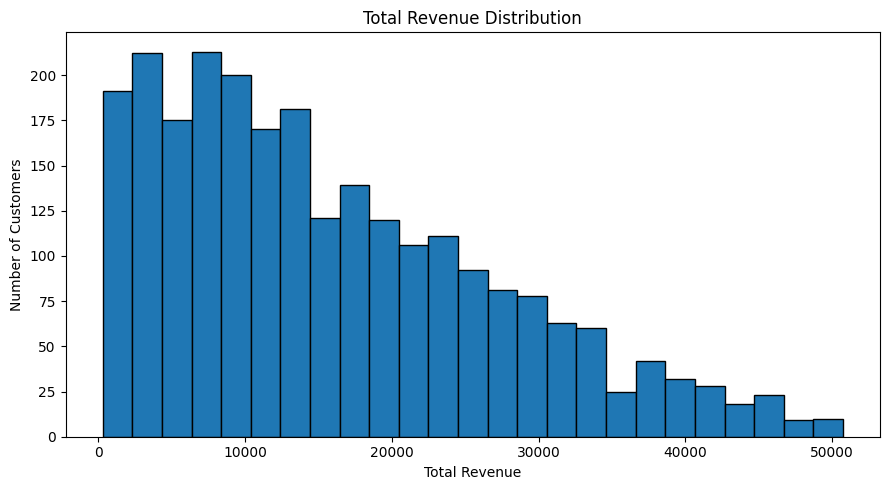

In [11]:
# 3. Total revenue distribution
plt.figure(figsize=(9, 5))
plt.hist(df["total_revenue"], bins=25, edgecolor="black")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")
plt.title("Total Revenue Distribution")
plt.tight_layout()
plt.show()


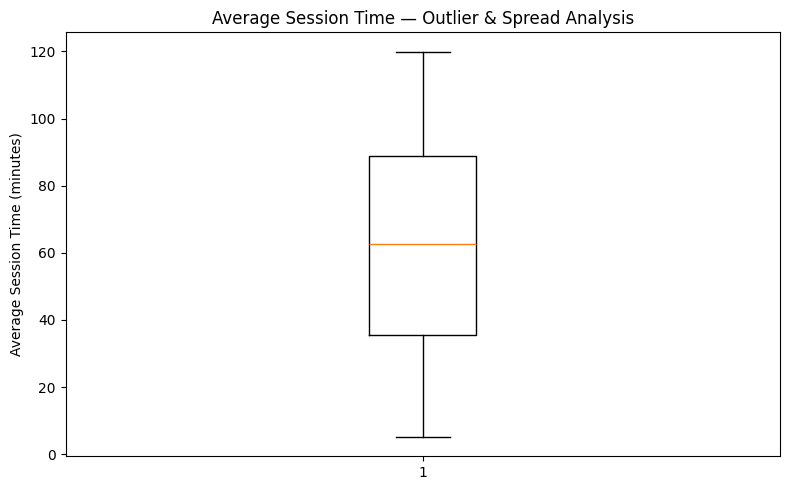

In [12]:
# 4. Average session time boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(df["avg_session_time"], vert=True)
plt.ylabel("Average Session Time (minutes)")
plt.title("Average Session Time — Outlier & Spread Analysis")
plt.tight_layout()
plt.show()


# 10. B. Categorical Business Insights

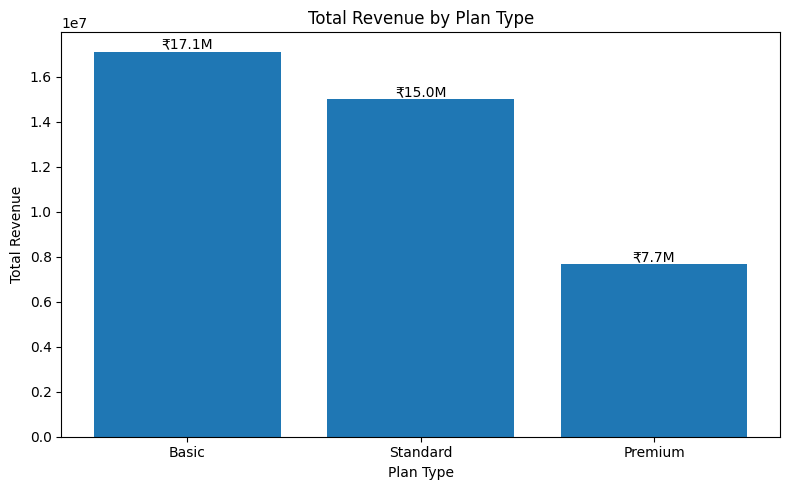

In [13]:
# 5. Revenue by plan type
plan_revenue = df.groupby("plan_type")["total_revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plan_revenue.index, plan_revenue.values)
plt.xlabel("Plan Type")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Plan Type")

for i, v in enumerate(plan_revenue.values):
    plt.text(i, v, f"₹{v/1e6:.1f}M", ha="center", va="bottom")

plt.tight_layout()
plt.show()


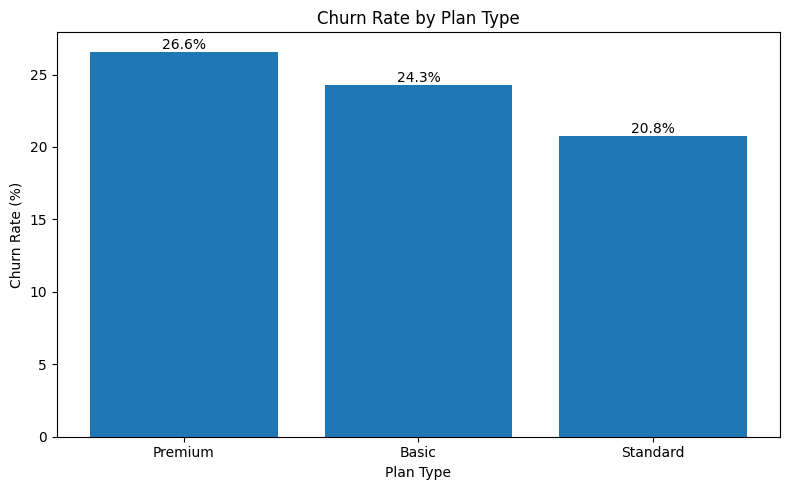

In [14]:
# 6. Churn rate by plan type
plan_churn = df.groupby("plan_type")["churn_flag"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
plt.bar(plan_churn.index, plan_churn.values)
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Plan Type")

for i, v in enumerate(plan_churn.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


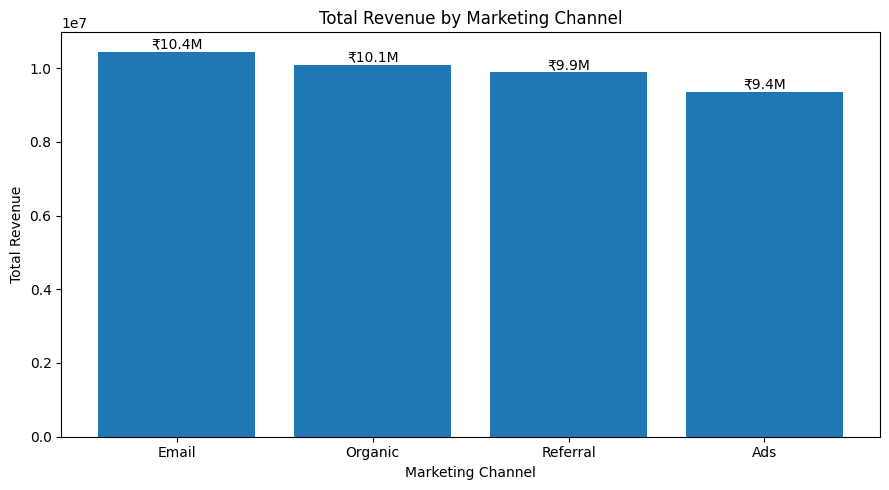

In [15]:
# 7. Revenue by marketing channel
channel_revenue = df.groupby("marketing_channel")["total_revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(channel_revenue.index, channel_revenue.values)
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Marketing Channel")

for i, v in enumerate(channel_revenue.values):
    plt.text(i, v, f"₹{v/1e6:.1f}M", ha="center", va="bottom")

plt.tight_layout()
plt.show()


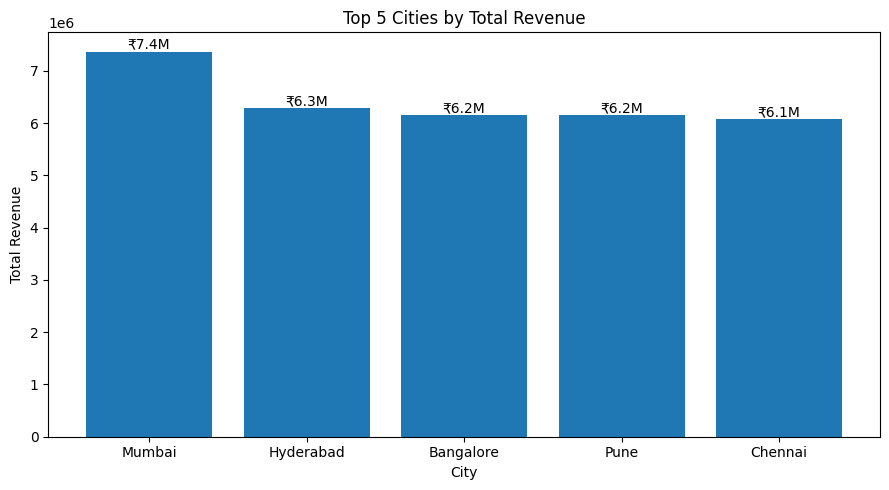

In [16]:
# 8. Revenue by city — Top 5
city_revenue = (
    df[df["city"] != "Unknown"]
    .groupby("city")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(9, 5))
plt.bar(city_revenue.index, city_revenue.values)
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Top 5 Cities by Total Revenue")

for i, v in enumerate(city_revenue.values):
    plt.text(i, v, f"₹{v/1e6:.1f}M", ha="center", va="bottom")

plt.tight_layout()
plt.show()


# 11. C. Behavioral & Time-Based Trends

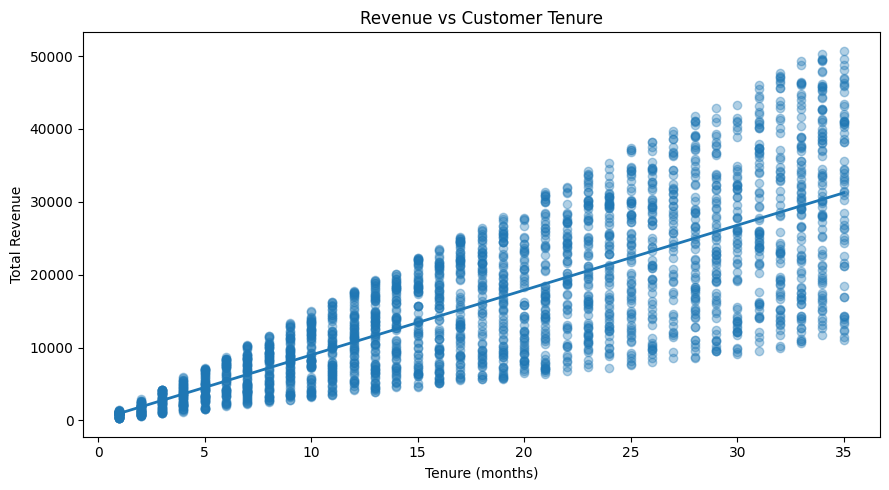

Approximate linear increase: ₹890.40 revenue per additional tenure month.


In [17]:
# 9. Revenue vs tenure with regression line
x = df["tenure_months"].values
y = df["total_revenue"].values

slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.35)
plt.plot(line_x, line_y, linewidth=2)
plt.xlabel("Tenure (months)")
plt.ylabel("Total Revenue")
plt.title("Revenue vs Customer Tenure")
plt.tight_layout()
plt.show()

print(f"Approximate linear increase: ₹{slope:,.2f} revenue per additional tenure month.")


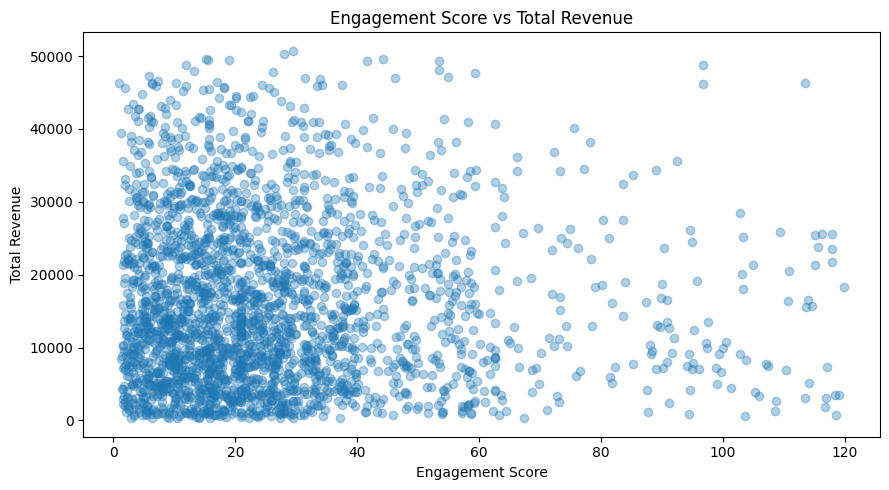

Correlation: -0.019


In [18]:
# 10. Engagement score vs revenue
plt.figure(figsize=(9, 5))
plt.scatter(df["engagement_score"], df["total_revenue"], alpha=0.35)
plt.xlabel("Engagement Score")
plt.ylabel("Total Revenue")
plt.title("Engagement Score vs Total Revenue")
plt.tight_layout()
plt.show()

print("Correlation:",
      df["engagement_score"].corr(df["total_revenue"]).round(3))


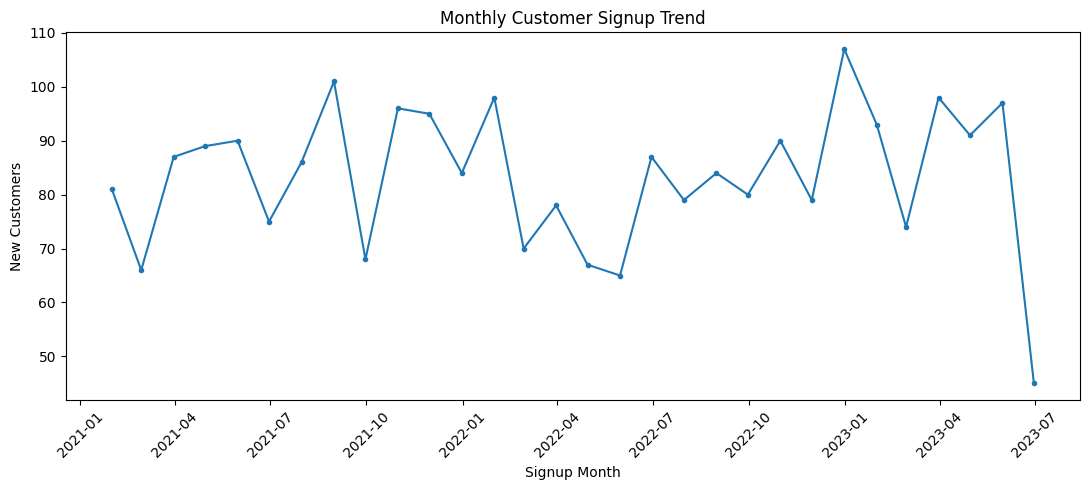

In [24]:
# 11. Signup trend over time
signup_trend = df.set_index("signup_date").resample("ME").size()
plt.figure(figsize=(11, 5))
plt.plot(signup_trend.index, signup_trend.values, marker="o", markersize=3)
plt.xlabel("Signup Month")
plt.ylabel("New Customers")
plt.title("Monthly Customer Signup Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


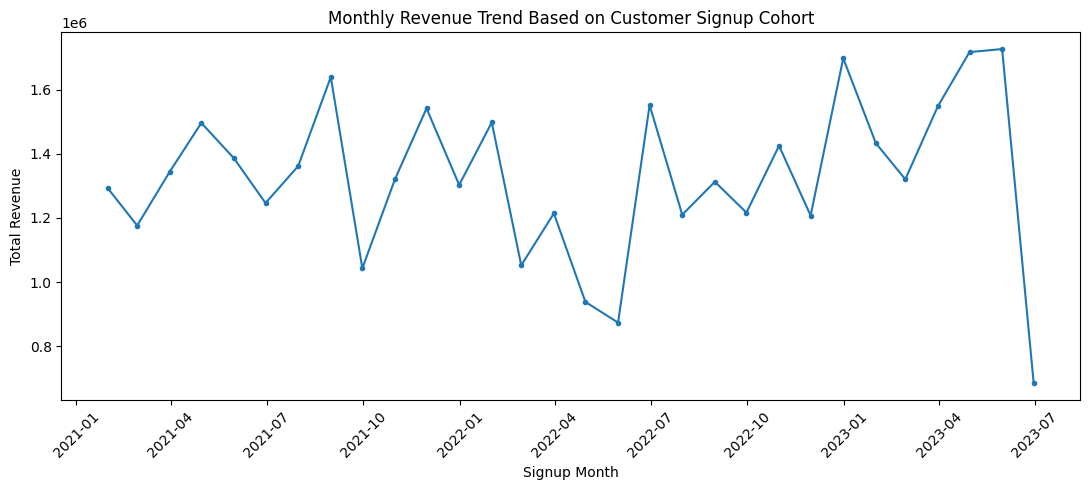

In [27]:
# 12. Monthly revenue trend
monthly_revenue = df.set_index("signup_date").resample("ME")["total_revenue"].sum()

plt.figure(figsize=(11, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", markersize=3)
plt.xlabel("Signup Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend Based on Customer Signup Cohort")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


> **Interpretation note:** The monthly revenue chart is a **signup-cohort revenue view** because `total_revenue` is customer-level cumulative revenue. It should not be described as recognized monthly accounting revenue. For true seasonality of recognized revenue, transaction-level monthly revenue data would be required.


# 12. Business Analysis Tables

In [28]:
# Plan performance
plan_summary = df.groupby("plan_type").agg(
    customers=("customer_id", "count"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    avg_monthly_fee=("monthly_fee", "mean"),
    avg_tenure=("tenure_months", "mean"),
    churn_rate=("churn_flag", "mean")
).sort_values("total_revenue", ascending=False)

plan_summary["churn_rate"] *= 100
display(plan_summary.round(2))

# Channel performance
channel_summary = df.groupby("marketing_channel").agg(
    customers=("customer_id", "count"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    churn_rate=("churn_flag", "mean")
).sort_values("avg_revenue", ascending=False)

channel_summary["churn_rate"] *= 100
display(channel_summary.round(2))

# City performance
city_summary = df.groupby("city").agg(
    customers=("customer_id", "count"),
    total_revenue=("total_revenue", "sum"),
    avg_revenue=("total_revenue", "mean"),
    churn_rate=("churn_flag", "mean")
).sort_values("total_revenue", ascending=False)

city_summary["churn_rate"] *= 100
display(city_summary.round(2))


,customers,total_revenue,avg_revenue,avg_monthly_fee,avg_tenure,churn_rate
plan_type,,,,,,
Basic,1101,"17,111,540.80","15,541.82",906.96,17.32,24.25
Standard,910,"15,005,696.75","16,489.78",898.78,18.41,20.77
Premium,489,"7,657,471.95","15,659.45",899.58,17.67,26.58


,customers,total_revenue,avg_revenue,churn_rate
marketing_channel,,,,
Organic,602,"10,089,889.25","16,760.61",23.75
Email,652,"10,446,037.05","16,021.53",25.15
Referral,637,"9,880,207.20","15,510.53",22.61
Ads,609,"9,358,576.00","15,367.12",22.17


,customers,total_revenue,avg_revenue,churn_rate
city,,,,
Mumbai,455,"7,370,886.15","16,199.75",23.52
Hyderabad,399,"6,293,485.05","15,773.15",20.80
Bangalore,387,"6,157,425.05","15,910.66",23.00
Pune,387,"6,150,315.30","15,892.29",23.77
Chennai,393,"6,079,883.95","15,470.44",23.41
Delhi,379,"6,024,531.70","15,895.86",23.22
Unknown,100,"1,698,182.30","16,981.82",35.00


# 13. Deeper Segment Analysis

In [29]:
# Revenue and churn by usage category
usage_summary = df.groupby("session_usage_category", observed=True).agg(
    customers=("customer_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    churn_rate=("churn_flag", "mean"),
    avg_session=("avg_session_time", "mean")
)
usage_summary["churn_rate"] *= 100
display(usage_summary.round(2))

# Revenue and churn by support intensity
support_summary = df.groupby("support_intensity").agg(
    customers=("customer_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    churn_rate=("churn_flag", "mean"),
    avg_tickets=("support_tickets", "mean")
)
support_summary["churn_rate"] *= 100
display(support_summary.round(2))

# Discount analysis
discount_summary = df.groupby("discount_category").agg(
    customers=("customer_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    churn_rate=("churn_flag", "mean"),
    avg_discount=("discount_percent", "mean")
)
discount_summary["churn_rate"] *= 100
display(discount_summary.round(2))


,customers,avg_revenue,churn_rate,avg_session
session_usage_category,,,,
High,1345,"15,505.62",23.42,87.88
Low,500,"16,106.01",20.20,17.63
Medium,655,"16,590.30",25.95,45.18


,customers,avg_revenue,churn_rate,avg_tickets
support_intensity,,,,
High,168,"15,387.68",21.43,5.55
Low,2332,"15,947.50",23.58,1.84


,customers,avg_revenue,churn_rate,avg_discount
discount_category,,,,
High Discount,958,"15,235.70",22.76,17.56
Low Discount,1065,"16,541.11",24.51,7.74
No Discount,477,"15,854.58",22.43,0.00


# 14. Correlation Heatmap

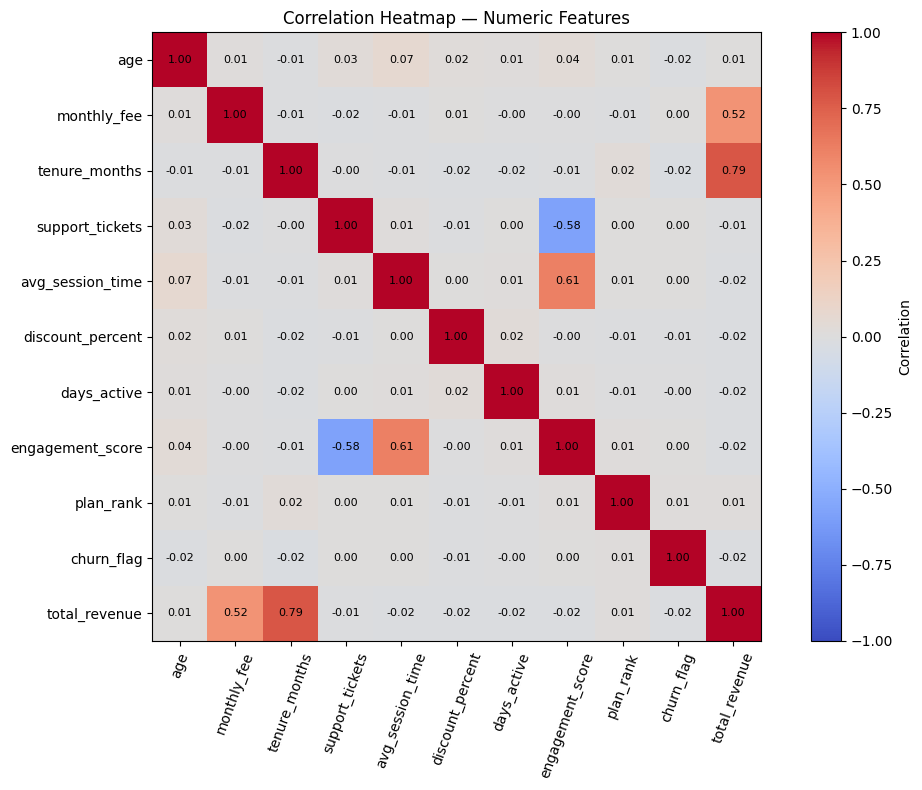

Top numeric correlations with revenue:


,correlation
tenure_months,0.79
monthly_fee,0.52
days_active,-0.02
discount_percent,-0.02
avg_session_time,-0.02
churn_flag,-0.02
engagement_score,-0.02
plan_rank,0.01
support_tickets,-0.01
age,0.01


In [30]:
# 13. Correlation heatmap
corr_cols = [
    "age", "monthly_fee", "tenure_months", "support_tickets",
    "avg_session_time", "discount_percent", "days_active",
    "engagement_score", "plan_rank", "churn_flag", "total_revenue"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

print("Top numeric correlations with revenue:")
display(
    corr["total_revenue"]
    .drop("total_revenue")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("correlation")
)


# 15. Revenue Forecasting — Linear Regression

### Target
`total_revenue`

### Candidate predictors
- age
- gender
- city
- monthly_fee
- tenure_months
- support_tickets
- avg_session_time
- discount_percent
- marketing_channel
- plan_type
- signup_year
- signup_month

### Leakage prevention
Do **not** use:
- `revenue_per_month` — directly calculated from the target
- `revenue_category` — directly based on revenue
- `high_value_customer` — directly based on revenue
- `total_revenue` — target itself
- `customer_id` — identifier, not a meaningful predictor
- `churned` / `churn_flag` — treated as an outcome rather than a pre-revenue predictor


In [31]:
# Prepare modeling dataset
features = [
    "age", "gender", "city", "monthly_fee", "tenure_months",
    "support_tickets", "avg_session_time", "discount_percent",
    "marketing_channel", "plan_type", "signup_year", "signup_month"
]

target = "total_revenue"

X = df[features]
y = df[target]

categorical_features = [
    "gender", "city", "marketing_channel", "plan_type", "signup_month"
]
numeric_features = [
    c for c in features if c not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"),
         categorical_features)
    ]
)

regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

regression_model.fit(X_train, y_train)
predictions = regression_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.3f}")


MAE  : ₹2,650.92
RMSE : ₹3,532.15
R²   : 0.899


### How to read the metrics

- **MAE:** average absolute prediction error in revenue units. Lower is better.
- **RMSE:** penalizes large errors more heavily. Lower is better.
- **R²:** percentage of variation in revenue explained by the model. Closer to 1 is better.

An R² around 0.90 would indicate a strong fit on this dataset, but it should still be validated on future/time-based data before production use.


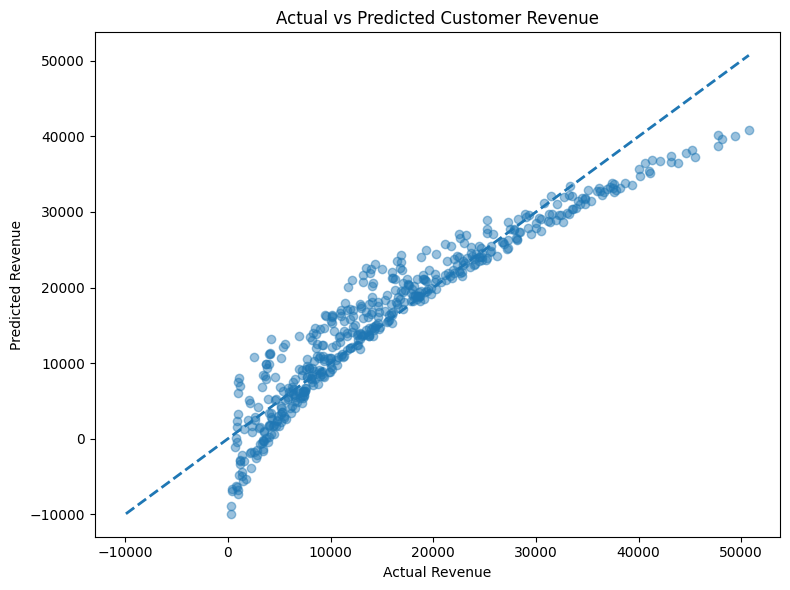

In [32]:
# 14. Actual vs Predicted Revenue
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.45)

min_value = min(y_test.min(), predictions.min())
max_value = max(y_test.max(), predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Customer Revenue")
plt.tight_layout()
plt.show()


# 16. Model Coefficients — Direction of Impact

In [33]:
# Coefficients after preprocessing
feature_names = regression_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = regression_model.named_steps["regressor"].coef_

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)

display(coef_table.head(15).round(2))


,feature,coefficient,abs_coefficient
2,num__tenure_months,"9,075.91","9,075.91"
1,num__monthly_fee,"6,042.23","6,042.23"
8,cat__gender_Other,685.05,685.05
16,cat__marketing_channel_Organic,494.15,494.15
30,cat__signup_month_September,-444.31,444.31
24,cat__signup_month_July,-438.01,438.01
20,cat__signup_month_August,-383.61,383.61
25,cat__signup_month_June,-349.45,349.45
26,cat__signup_month_March,-349.30,349.30
11,cat__city_Hyderabad,323.74,323.74


### Coefficient caution

Numeric variables are standardized before regression, so their coefficients represent the estimated revenue change associated with a **one-standard-deviation change**, holding other variables constant.

Categorical coefficients compare a category with the omitted reference category. These coefficients show **association, not causation**.


# 17. Customer Segmentation for Action

In [34]:
# High-value customers
high_value_summary = df.groupby("high_value_customer").agg(
    customers=("customer_id", "count"),
    avg_revenue=("total_revenue", "mean"),
    avg_tenure=("tenure_months", "mean"),
    churn_rate=("churn_flag", "mean"),
    avg_engagement=("engagement_score", "mean")
)
high_value_summary["churn_rate"] *= 100
display(high_value_summary.round(2))

# Highest-value individual customer profiles
top_customers = df.sort_values("total_revenue", ascending=False)[[
    "customer_id", "city", "plan_type", "monthly_fee",
    "tenure_months", "avg_session_time", "support_tickets",
    "discount_percent", "churned", "total_revenue"
]].head(10)

display(top_customers)


,customers,avg_revenue,avg_tenure,churn_rate,avg_engagement
high_value_customer,,,,,
No,1250,"6,751.06",10.92,24.32,26.53
Yes,1250,"25,068.71",24.65,22.56,25.90


,customer_id,city,plan_type,monthly_fee,tenure_months,avg_session_time,support_tickets,discount_percent,churned,total_revenue
1567,11568,Bangalore,Standard,1456,35,118.06,3,15.00,No,"50,741.60"
222,10223,Delhi,Standard,1484,34,111.64,3,10.00,No,"50,307.60"
1887,11888,Delhi,Basic,1420,35,88.59,1,5.00,Yes,"49,629.00"
1846,11847,Pune,Standard,1458,34,30.26,1,0.00,Yes,"49,572.00"
376,10377,Chennai,Premium,1461,34,37.98,1,10.00,No,"49,527.90"
2391,12392,Pune,Premium,1461,34,62.31,3,10.00,No,"49,527.90"
1405,11406,Unknown,Standard,1452,34,53.50,0,0.00,Yes,"49,368.00"
2236,12237,Mumbai,Basic,1499,33,83.23,1,10.00,No,"49,317.10"
1413,11414,Chennai,Premium,1397,35,35.48,2,5.00,Yes,"48,825.15"
640,10641,Pune,Basic,1479,33,96.75,0,5.00,No,"48,733.05"


# 18. Executive Business Insights

## Key findings from this dataset

### 1. Tenure is the strongest revenue driver
`tenure_months` has a strong positive relationship with `total_revenue`. This means retaining customers and increasing customer lifetime can materially increase revenue.

**Business action:** prioritize onboarding, renewal journeys, loyalty benefits and early churn intervention.

### 2. Pricing also matters
`monthly_fee` has a meaningful positive relationship with total revenue.

**Business action:** test plan upgrades and value-based pricing instead of relying only on discounts.

### 3. Standard plan is especially efficient
In this dataset, the Standard plan has the highest average customer revenue while also having the lowest churn rate among the three plans.

**Business action:** investigate what makes Standard attractive and consider it as the default upgrade path.

### 4. Organic customers show strong revenue quality
Organic acquisition has the highest average revenue per customer among the marketing channels.

**Business action:** invest in SEO/content/referral-like organic acquisition and compare customer lifetime value, not just acquisition volume.

### 5. Mumbai is the largest city-level revenue contributor
Mumbai contributes the highest total revenue among the named cities in the dataset.

**Business action:** protect this market while identifying why other cities have lower contribution.

### 6. Churn is a material business risk
Overall churn is roughly one quarter of the customer base in this dataset.

**Business action:** create a churn-risk dashboard using tenure, usage, support interactions and recent activity.

### 7. More usage does not automatically mean more revenue
The engagement score has only a weak relationship with total revenue in this dataset.

**Business action:** do not use session time alone as a value proxy. Combine usage with tenure, plan, pricing and retention.

### 8. Data quality itself is a business issue
The raw file contains duplicate records, missing values and many records where `last_active_date` occurs before `signup_date`.

**Business action:** add source-system validation rules for customer IDs and date logic before data reaches analytics dashboards.

### 9. Revenue is concentrated
The revenue distribution is right-skewed, meaning a smaller group of customers contributes disproportionately more revenue.

**Business action:** use high-value customer segmentation and protect those customers with retention programs.


# 19. Recommended Business Strategy

| Priority | Action | Why |
|---|---|---|
| 🔴 High | Reduce early churn | Retention increases customer lifetime and revenue |
| 🔴 High | Protect high-value customers | Revenue is concentrated among stronger customers |
| 🟠 Medium | Promote Standard plan intelligently | Strong average revenue + lower churn in this sample |
| 🟠 Medium | Expand Organic acquisition | Highest average revenue per acquired customer |
| 🟡 Medium | Improve data quality | Invalid dates and duplicates can distort KPIs |
| 🟡 Medium | Build cohort analysis | Understand how acquisition month/year affects lifetime value |

### Suggested management KPIs
- Customer count
- Total revenue
- Average revenue per customer
- Revenue per month
- Churn rate
- Average tenure
- High-value customer percentage
- Revenue by plan
- Revenue by channel
- Revenue by city
- Revenue forecast MAE / RMSE / R²


# 20. Save Cleaned Dataset

In [35]:
# Export analysis-ready dataset
output_file = "customer_analytics_cleaned.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")
print("Final shape:", df.shape)


Cleaned dataset saved as: customer_analytics_cleaned.csv
Final shape: (2500, 29)


# 🎯 Final Project Conclusion

This project converts raw subscription data into an **analysis-ready customer analytics solution**.

The analysis shows that **customer tenure and pricing are the major revenue-related factors**, while plan, acquisition channel, geography, usage and support behavior provide useful segmentation context.

The Linear Regression model provides a quantitative baseline for revenue estimation. However, before production deployment, the next improvements should be:

1. Validate the model on a **time-based holdout**.
2. Compare Linear Regression with **Random Forest / Gradient Boosting**.
3. Add transaction-level revenue data for true monthly forecasting.
4. Build a dedicated churn prediction model.
5. Deploy the KPIs in Power BI/Tableau or a Python dashboard.
6. Add automated data-quality checks for duplicate IDs and invalid dates.

**Portfolio headline:**  
> *Built an end-to-end customer analytics and revenue forecasting pipeline using Pandas, NumPy, Matplotlib and Scikit-learn, covering data quality, feature engineering, segmentation, business insights and predictive modeling.*
